In [1]:
# ============================================================
# RETAIL ROCKET E-COMMERCE ANALYSIS 
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3

EVENTS_PATH = r"C:\Users\LENOVO\Downloads\RETAIL_ROCKET_E-COMMERCE _FUNNEL_ANALYSIS\events.csv"
CAT_TREE_PATH = r"C:\Users\LENOVO\Downloads\RETAIL_ROCKET_E-COMMERCE _FUNNEL_ANALYSIS\category_tree.csv"
ITEM_PROP1_PATH = r"C:\Users\LENOVO\Downloads\RETAIL_ROCKET_E-COMMERCE _FUNNEL_ANALYSIS\item_properties_part1.csv"
ITEM_PROP2_PATH = r"C:\Users\LENOVO\Downloads\RETAIL_ROCKET_E-COMMERCE _FUNNEL_ANALYSIS\item_properties_part2.csv"


os.makedirs('project_outputs', exist_ok=True)
print(" RETAIL ROCKET E-COMMERCE ANALYSIS \n")

 RETAIL ROCKET E-COMMERCE ANALYSIS 



In [10]:

print("Step 2: Loading all 4 files...")

# Load Events
events = pd.read_csv(EVENTS_PATH)
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')
print(" Events loaded")

# Load Category Tree
category_tree = pd.read_csv(CAT_TREE_PATH)
print(" Category Tree loaded")

# Load Item Properties (Only 3 columns)
item_prop1 = pd.read_csv(ITEM_PROP1_PATH, usecols=['itemid', 'property', 'value'])
item_prop2 = pd.read_csv(ITEM_PROP2_PATH, usecols=['itemid', 'property', 'value'])
item_properties = pd.concat([item_prop1, item_prop2], ignore_index=True)

# Extract Category
categories = item_properties[item_properties['property'] == 'category'][['itemid', 'value']].copy()
categories.columns = ['itemid', 'categoryid']
categories['categoryid'] = pd.to_numeric(categories['categoryid'], errors='coerce')

# Extract Price (CORRECT ORDER)
prices = item_properties[item_properties['property'] == 'price'][['itemid', 'value']].copy()
prices['price'] = pd.to_numeric(prices['value'], errors='coerce')   # ← Convert FIRST
prices = prices[['itemid', 'price']]                                 # ← Then keep only these columns

print(" Category and Price extracted\n")



Step 2: Loading all 4 files...
 Events loaded
 Category Tree loaded
 Category and Price extracted



In [3]:

print("Step 3: Combining all data...")

events = events.merge(categories, on='itemid', how='left')
events = events.merge(prices, on='itemid', how='left')

print(" All data combined\n")

Step 3: Combining all data...
 All data combined



In [4]:

print("Step 4: Loading into SQL...")

conn = sqlite3.connect(':memory:')
events.to_sql('events', conn, index=False)
print(" Data loaded into SQL\n")

Step 4: Loading into SQL...
 Data loaded into SQL



In [5]:

print("Step 5: Cleaning data...")

conn.execute("""
    DELETE FROM events 
    WHERE rowid NOT IN (
        SELECT MIN(rowid) 
        FROM events 
        GROUP BY visitorid, timestamp, event, itemid
    )
""")
conn.commit()
print(" Data cleaned\n")

Step 5: Cleaning data...
 Data cleaned



Step 6: Understanding events...
Event Distribution:
         event  total_count
0         view      2664218
1    addtocart        68966
2  transaction        22457


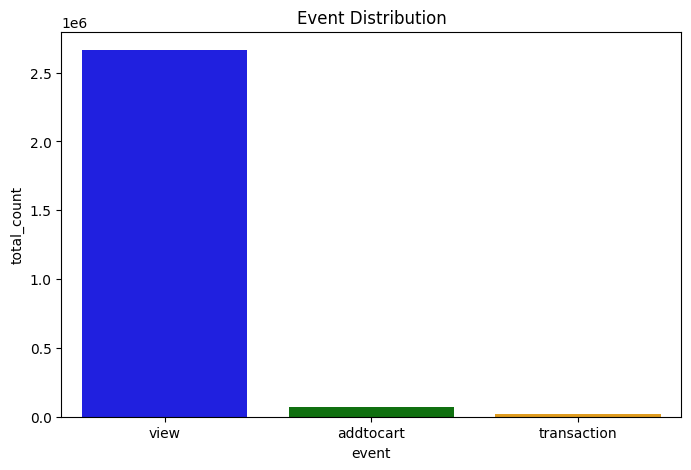

In [6]:

print("Step 6: Understanding events...")

event_query = """
    SELECT event, COUNT(*) as total_count
    FROM events
    GROUP BY event
    ORDER BY total_count DESC
"""

event_result = pd.read_sql_query(event_query, conn)
print("Event Distribution:")
print(event_result)
plt.figure(figsize=(8,5))
sns.barplot(data=event_result, x='event', y='total_count', hue='event', palette=['blue','green','orange'], legend=False)
plt.title("Event Distribution")
plt.savefig("project_outputs/eda_1_event_distribution.png")
plt.show()

Step 7: Building Conversion Funnel (Using SQL)...
=== FUNNEL RESULTS ===
View → Add to Cart     : 2.69%
Add to Cart → Buy      : 31.07%
Overall Conversion     : 0.83%


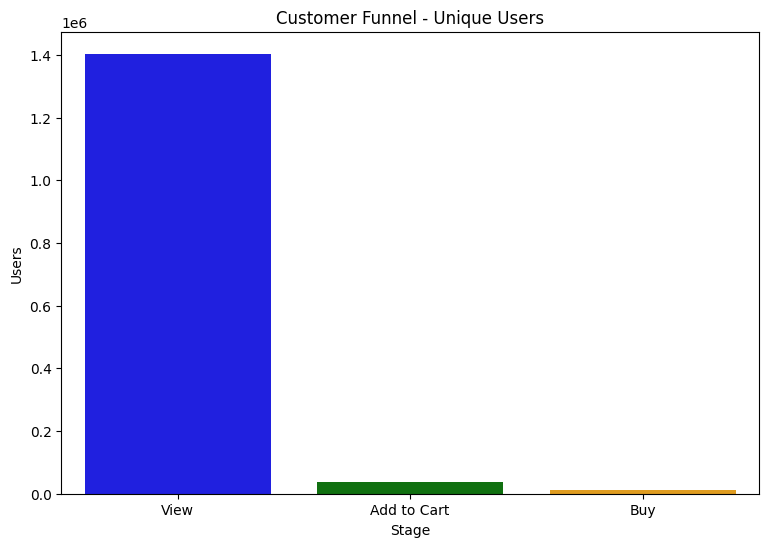

In [7]:

print("Step 7: Building Conversion Funnel (Using SQL)...")

funnel_query = """
    SELECT 
        event,
        COUNT(DISTINCT visitorid) as unique_users
    FROM events
    WHERE event IN ('view', 'addtocart', 'transaction')
    GROUP BY event
"""

funnel = pd.read_sql_query(funnel_query, conn)

view_users = int(funnel[funnel['event'] == 'view']['unique_users'].iloc[0])
addtocart_users = int(funnel[funnel['event'] == 'addtocart']['unique_users'].iloc[0])
buy_users = int(funnel[funnel['event'] == 'transaction']['unique_users'].iloc[0])

view_to_cart = (addtocart_users / view_users) * 100
cart_to_buy = (buy_users / addtocart_users) * 100
overall = (buy_users / view_users) * 100

print("=== FUNNEL RESULTS ===")
print(f"View → Add to Cart     : {view_to_cart:.2f}%")
print(f"Add to Cart → Buy      : {cart_to_buy:.2f}%")
print(f"Overall Conversion     : {overall:.2f}%")

funnel_plot = pd.DataFrame({
    'Stage': ['View', 'Add to Cart', 'Buy'],
    'Users': [view_users, addtocart_users, buy_users]
})

plt.figure(figsize=(9,6))
sns.barplot(x='Stage', y='Users', data=funnel_plot, 
            hue='Stage', 
            palette=['blue','green','orange'], 
            legend=False)
plt.title("Customer Funnel - Unique Users")
plt.savefig("project_outputs/funnel_chart.png")
plt.show()

In [8]:

print("Step 8: Finding best time to buy (Using SQL)...")

hour_query = """
    SELECT 
        strftime('%H', timestamp) as hour,
        COUNT(*) as total_events
    FROM events
    GROUP BY hour
"""

best_hours = pd.read_sql_query(hour_query, conn)
print("Events by Hour of Day:")
print(best_hours.head(10))

print("\n Highest customer activity happens between 12:00 AM to 5:00 AM UTC (midnight to early morning).\n")

Step 8: Finding best time to buy (Using SQL)...
Events by Hour of Day:
  hour  total_events
0   00        144278
1   01        140673
2   02        145854
3   03        150831
4   04        147153
5   05        119558
6   06         76965
7   07         43936
8   08         25304
9   09         17905

 Highest customer activity happens between 12:00 AM to 5:00 AM UTC (midnight to early morning).



In [9]:

sample_data = events[['timestamp', 'visitorid', 'event', 'itemid']].head(500000)

sample_data.to_csv('tableau_sample.csv', index=False)

print(" Sample file created successfully!")
print("File name: tableau_sample.csv")


 Sample file created successfully!
File name: tableau_sample.csv
